# Hospital Patient Experience Analysis

## Exploratory Data Analysis and Technology Opportunity Identification

This project analyses patient-experience data from 4,792 hospitals across the United States.

The analysis focuses on hospital ratings, nurse communication, doctor communication, discharge information, and patient recommendations.

The main objective is to identify patterns in hospital performance and detect areas where digital solutions could improve the patient experience.

---

## Business Problem

Hospitals collect patient-experience information, but raw survey scores do not directly show:

- Which hospitals require the most improvement.
- Which patient-experience areas are underperforming.
- Which states have the strongest or weakest hospital performance.
- Which factors are most strongly associated with patient recommendations.
- Which digital solutions may address common hospital performance gaps.

This project transforms hospital survey data into useful findings and technology opportunity recommendations.

---

## Project Objectives

1. Assess the quality and completeness of the dataset.
2. Analyse the distribution of hospital patient-experience scores.
3. Compare hospital performance across states and cities.
4. Measure relationships between communication, discharge information, and patient recommendations.
5. Identify hospitals with multiple low-performing indicators.
6. Create a technology opportunity score.
7. Recommend suitable digital solutions based on each hospital's weakest area.

## Research Questions

This analysis aims to answer the following questions:

1. What is the distribution of overall hospital ratings?
2. What are the average patient-experience scores?
3. Which states contain the largest number of hospitals?
4. Which states have the highest and lowest patient recommendation scores?
5. Is nurse communication associated with patient recommendations?
6. Is doctor communication associated with patient recommendations?
7. Is discharge information associated with patient recommendations?
8. Which metric has the strongest relationship with patient recommendation?
9. Which hospitals perform poorly across several patient-experience indicators?
10. Which technical solutions could address the most common performance gaps?

In [1]:
# Import the required libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Configure pandas display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

## 1. Load the Dataset

The dataset contains hospital-level patient-experience measures.

The `facility_id` column is loaded as a string because some hospital identifiers begin with zero.

In [3]:
# Define the dataset path

file_path = Path("hospital dataset.csv")

# Load the dataset

df = pd.read_csv(
    file_path,
    dtype={"facility_id": "string"}
)

# Display the first five rows

df.head()

,facility_id,facility_name,city,state,overall_rating,nurse_communication,doctor_communication,discharge_information,patient_recommendation
0,020026,ALASKA NATIVE MEDICAL CENTER,ANCHORAGE,AK,3.00,89.00,89.00,83.00,85.00
1,020017,ALASKA REGIONAL HOSPITAL,ANCHORAGE,AK,3.00,91.00,90.00,85.00,87.00
2,020001,PROVIDENCE ALASKA MEDICAL CENTER,ANCHORAGE,AK,3.00,91.00,90.00,90.00,91.00
3,021312,SAMUEL SIMMONDS MEMORIAL HOSPITAL,BARROW,AK,NaN,NaN,NaN,NaN,NaN
4,020018,YUKON KUSKOKWIM DELTA REG HOSPITAL,BETHEL,AK,3.00,90.00,90.00,79.00,87.00


## 2. Initial Data Inspection

The first stage of the analysis is to understand the structure, size, columns, and data types of the dataset.

In [4]:
# Display the dataset dimensions

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 4,792
Number of columns: 9


In [5]:
# Display the column names

df.columns.tolist()

['facility_id',
 'facility_name',
 'city',
 'state',
 'overall_rating',
 'nurse_communication',
 'doctor_communication',
 'discharge_information',
 'patient_recommendation']

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4792 entries, 0 to 4791
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   facility_id             4792 non-null   string 
 1   facility_name           4792 non-null   str    
 2   city                    4792 non-null   str    
 3   state                   4792 non-null   str    
 4   overall_rating          3176 non-null   float64
 5   nurse_communication     3176 non-null   float64
 6   doctor_communication    3176 non-null   float64
 7   discharge_information   3176 non-null   float64
 8   patient_recommendation  3176 non-null   float64
dtypes: float64(5), str(3), string(1)
memory usage: 337.1 KB


In [7]:
# Display a random sample

df.sample(5, random_state=42)

,facility_id,facility_name,city,state,overall_rating,nurse_communication,doctor_communication,discharge_information,patient_recommendation
561,050690,KAISER FOUNDATION HOSPITAL-SANTA ROSA,SANTA ROSA,CA,3.00,91.00,91.00,86.00,89.00
893,100077,Adventhealth Port Charlotte,PORT CHARLOTTE,FL,2.00,87.00,84.00,81.00,78.00
1684,170200,"VIA CHRISTI HOSPITAL WICHITA ST TERESA, INC",WICHITA,KS,3.00,92.00,91.00,82.00,92.00
705,061326,UCHEALTH PIKES PEAK REGIONAL HOSPITAL,WOODLAND PARK,CO,NaN,NaN,NaN,NaN,NaN
1873,19043F,ALEXANDRIA VA MEDICAL CENTER,PINEVILLE,LA,NaN,NaN,NaN,NaN,NaN


In [8]:
# Display descriptive statistics for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
overall_rating,3176.00,3.29,0.88,1.00,3.00,3.00,4.00,5.00
nurse_communication,3176.00,91.24,2.63,74.00,90.00,91.00,93.00,100.00
doctor_communication,3176.00,90.67,2.67,74.00,89.00,91.00,92.00,100.00
discharge_information,3176.00,85.66,3.96,65.00,83.00,86.00,88.00,99.00
patient_recommendation,3176.00,86.96,4.75,60.00,84.00,87.00,90.00,98.00


In [9]:
# Count unique values in each column

unique_values = df.nunique().sort_values(ascending=False)

unique_values

facility_id               4792
facility_name             4672
city                      2925
state                       56
patient_recommendation      36
discharge_information       32
doctor_communication        26
nurse_communication         24
overall_rating               5
dtype: int64

### Initial Observations

The dataset contains:

- 4,792 hospital records.
- 9 columns.
- A unique identifier for each hospital.
- Hospital location information.
- One overall rating metric.
- Four patient-experience indicators.

The patient-experience indicators are:

- Nurse communication.
- Doctor communication.
- Discharge information.
- Patient recommendation.

## 3. Data Quality Assessment

Before analysing the hospital scores, the dataset must be checked for:

- Duplicate records.
- Duplicate hospital identifiers.
- Missing values.
- Incorrect data types.
- Invalid numerical ranges.
- Inconsistent text formatting.

In [10]:
# Count fully duplicated rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicated rows: {duplicate_rows}")

Duplicated rows: 0


In [11]:
# Check for duplicated hospital identifiers

duplicate_facility_ids = df["facility_id"].duplicated().sum()

print(f"Duplicated facility IDs: {duplicate_facility_ids}")

Duplicated facility IDs: 0


In [12]:
# Create a missing-values summary

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean().mul(100)
}).sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
overall_rating,1616,33.72
patient_recommendation,1616,33.72
discharge_information,1616,33.72
doctor_communication,1616,33.72
nurse_communication,1616,33.72
facility_id,0,0.00
state,0,0.00
facility_name,0,0.00
city,0,0.00


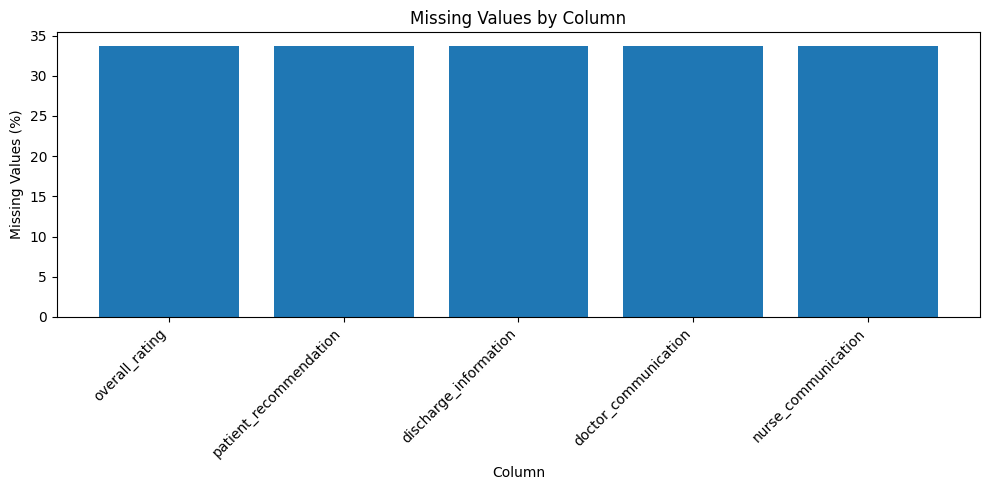

In [13]:
# Plot missing-value percentages

missing_plot_data = missing_summary[
    missing_summary["missing_count"] > 0
]

plt.figure(figsize=(10, 5))

plt.bar(
    missing_plot_data.index,
    missing_plot_data["missing_percentage"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Missing-Value Decision

The hospital rating columns contain missing values.

These missing scores should not be replaced with zero because zero would incorrectly represent extremely poor hospital performance.

They should also not be replaced with the overall mean because this would create artificial hospital ratings.

The following strategy will be used:

- Keep all hospitals for geographic and hospital-count analyses.
- Use hospitals with complete patient-experience data for score-based analyses.
- Preserve the original missing values.
- Create an indicator showing whether complete experience data are available.

## 4. Data Cleaning

The cleaning process includes:

1. Standardising text values.
2. Converting score columns to numerical values.
3. Checking valid score ranges.
4. Removing duplicated records if any are found.
5. Creating a separate dataset for hospitals with complete patient-experience information.

In [14]:
# Create a copy before cleaning

clean_df = df.copy()

# Remove fully duplicated rows

clean_df = clean_df.drop_duplicates().copy()

print(f"Rows after duplicate removal: {len(clean_df):,}")

Rows after duplicate removal: 4,792


In [15]:
# Standardise text columns

text_columns = [
    "facility_name",
    "city",
    "state"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

In [16]:
# Define the numerical score columns

numeric_columns = [
    "overall_rating",
    "nurse_communication",
    "doctor_communication",
    "discharge_information",
    "patient_recommendation"
]

# Convert score columns to numeric values

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

In [17]:
# Check the minimum and maximum values

score_ranges = clean_df[numeric_columns].agg(
    ["min", "max"]
).T

score_ranges

,min,max
overall_rating,1.00,5.00
nurse_communication,74.00,100.00
doctor_communication,74.00,100.00
discharge_information,65.00,99.00
patient_recommendation,60.00,98.00


In [18]:
# Identify invalid overall ratings

invalid_overall_ratings = clean_df[
    clean_df["overall_rating"].notna()
    & ~clean_df["overall_rating"].between(1, 5)
]

print(
    "Invalid overall rating records:",
    len(invalid_overall_ratings)
)

Invalid overall rating records: 0


In [19]:
# Define the percentage-based patient-experience columns

percentage_columns = [
    "nurse_communication",
    "doctor_communication",
    "discharge_information",
    "patient_recommendation"
]

# Find records containing values outside the valid 0–100 range

invalid_percentage_mask = pd.Series(
    False,
    index=clean_df.index
)

for column in percentage_columns:
    invalid_percentage_mask |= (
        clean_df[column].notna()
        & ~clean_df[column].between(0, 100)
    )

invalid_percentage_scores = clean_df[
    invalid_percentage_mask
]

print(
    "Records with invalid percentage scores:",
    len(invalid_percentage_scores)
)

Records with invalid percentage scores: 0


In [20]:
# Replace invalid scores with missing values if any exist

clean_df.loc[
    clean_df["overall_rating"].notna()
    & ~clean_df["overall_rating"].between(1, 5),
    "overall_rating"
] = np.nan

for column in percentage_columns:
    clean_df.loc[
        clean_df[column].notna()
        & ~clean_df[column].between(0, 100),
        column
    ] = np.nan

In [21]:
# Create an indicator for complete experience data

clean_df["has_complete_experience_data"] = (
    clean_df[numeric_columns]
    .notna()
    .all(axis=1)
)

clean_df[
    "has_complete_experience_data"
].value_counts()

has_complete_experience_data
True     3176
False    1616
Name: count, dtype: int64

In [22]:
# Create a dataset containing complete patient-experience records

experience_df = clean_df[
    clean_df["has_complete_experience_data"]
].copy()

print(f"All hospital records: {len(clean_df):,}")
print(
    "Hospitals with complete experience data:",
    f"{len(experience_df):,}"
)

complete_percentage = (
    len(experience_df) / len(clean_df) * 100
)

print(
    f"Complete-data percentage: "
    f"{complete_percentage:.2f}%"
)

All hospital records: 4,792
Hospitals with complete experience data: 3,176
Complete-data percentage: 66.28%


### Cleaning Result

The cleaned dataset retains all hospital records for geographic analysis.

A second dataset named `experience_df` contains only hospitals with complete patient-experience scores.

This approach prevents artificial values from being introduced while allowing reliable comparisons between hospital performance indicators.

## 5. Descriptive Statistics

Descriptive statistics summarise the central tendency and spread of each patient-experience metric.

In [23]:
# Descriptive statistics for complete patient-experience records

experience_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
overall_rating,3176.00,3.29,0.88,1.00,3.00,3.00,4.00,5.00
nurse_communication,3176.00,91.24,2.63,74.00,90.00,91.00,93.00,100.00
doctor_communication,3176.00,90.67,2.67,74.00,89.00,91.00,92.00,100.00
discharge_information,3176.00,85.66,3.96,65.00,83.00,86.00,88.00,99.00
patient_recommendation,3176.00,86.96,4.75,60.00,84.00,87.00,90.00,98.00


In [24]:
# Calculate standard deviations

experience_df[numeric_columns].std().to_frame(
    name="standard_deviation"
)

,standard_deviation
overall_rating,0.88
nurse_communication,2.63
doctor_communication,2.67
discharge_information,3.96
patient_recommendation,4.75


## 6. Univariate Analysis

Univariate analysis examines each variable separately.

This section analyses:

- Overall hospital ratings.
- Nurse communication.
- Doctor communication.
- Discharge information.
- Patient recommendations.


In [25]:
# Count hospitals by overall rating

rating_counts = (
    experience_df["overall_rating"]
    .value_counts()
    .sort_index()
)

rating_counts

overall_rating
1.00      51
2.00     501
3.00    1344
4.00    1037
5.00     243
Name: count, dtype: int64

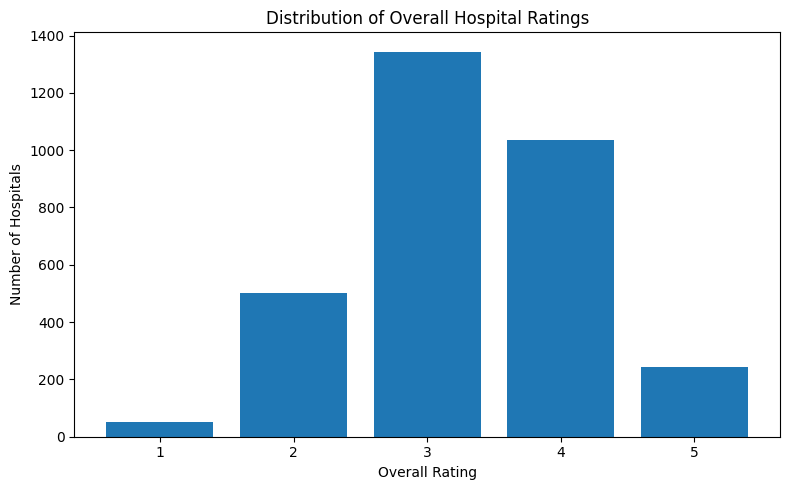

In [26]:
# Plot the overall-rating distribution

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(int).astype(str),
    rating_counts.values
)

plt.title("Distribution of Overall Hospital Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

### Interpretation

The chart shows how hospitals are distributed across ratings from one to five.

The most common rating should be identified from the chart and frequency table.

The analysis should also examine whether hospitals are concentrated around average ratings or whether many hospitals receive very high or very low ratings.

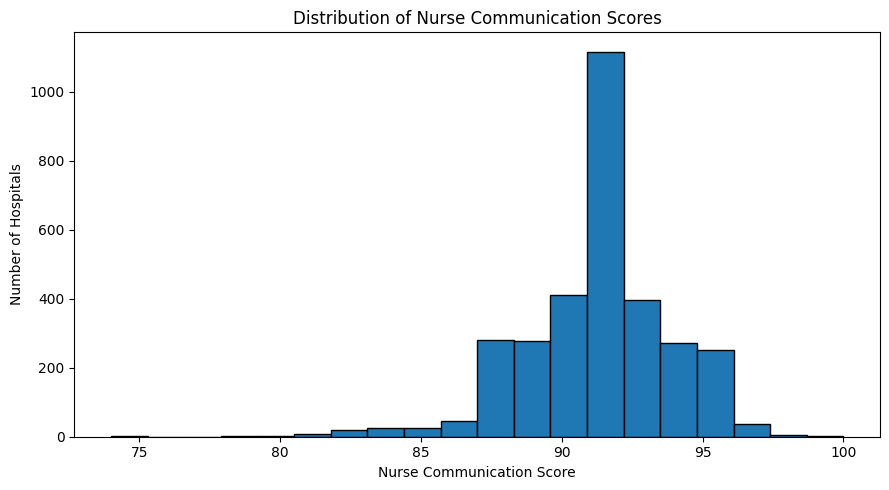

In [27]:
# Plot the nurse communication distribution

plt.figure(figsize=(9, 5))

plt.hist(
    experience_df["nurse_communication"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Nurse Communication Scores")
plt.xlabel("Nurse Communication Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

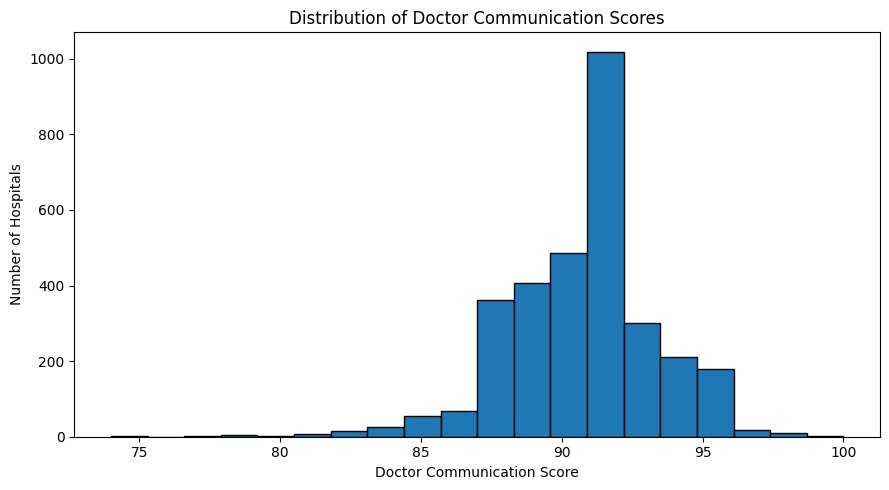

In [28]:
# Plot the doctor communication distribution

plt.figure(figsize=(9, 5))

plt.hist(
    experience_df["doctor_communication"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Doctor Communication Scores")
plt.xlabel("Doctor Communication Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

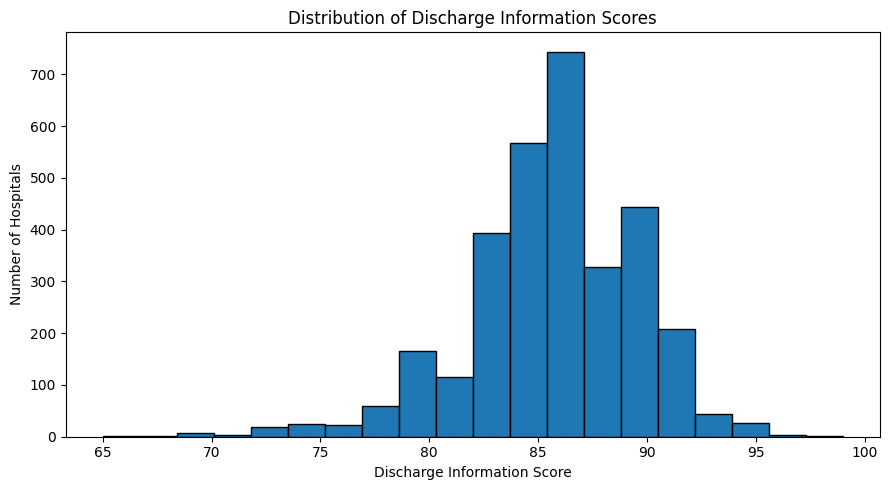

In [29]:
# Plot the discharge information distribution

plt.figure(figsize=(9, 5))

plt.hist(
    experience_df["discharge_information"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Discharge Information Scores")
plt.xlabel("Discharge Information Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

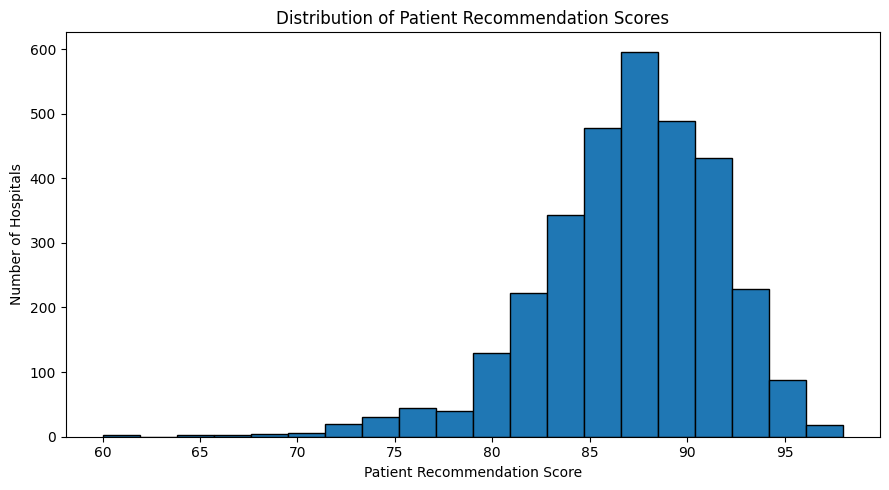

In [30]:
# Plot the patient recommendation distribution

plt.figure(figsize=(9, 5))

plt.hist(
    experience_df["patient_recommendation"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Patient Recommendation Scores")
plt.xlabel("Patient Recommendation Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

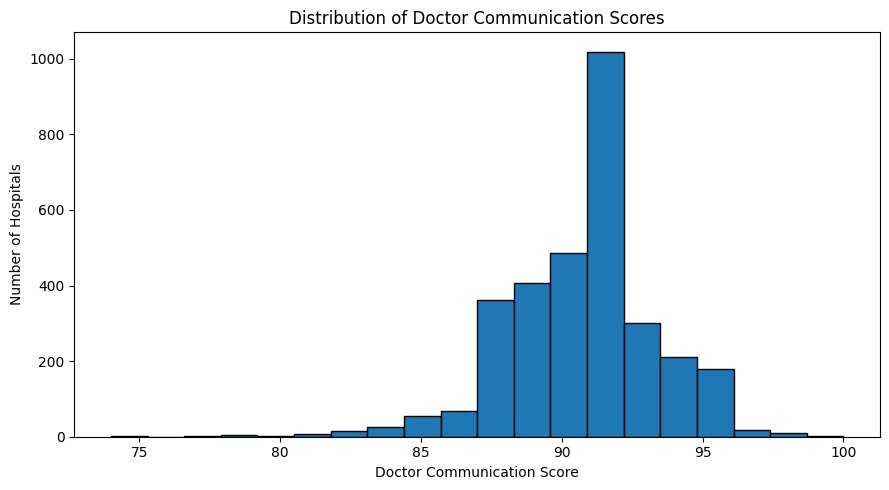

In [31]:
# Plot the doctor communication distribution

plt.figure(figsize=(9, 5))

plt.hist(
    experience_df["doctor_communication"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Doctor Communication Scores")
plt.xlabel("Doctor Communication Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

In [32]:
# Compare the average patient-experience metrics

average_scores = (
    experience_df[percentage_columns]
    .mean()
    .sort_values()
)

average_scores

discharge_information    85.66
patient_recommendation   86.96
doctor_communication     90.67
nurse_communication      91.24
dtype: float64

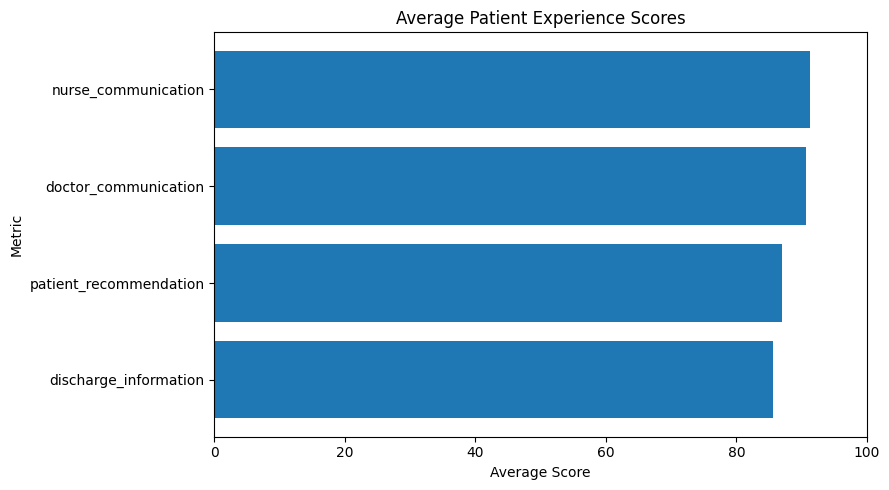

In [33]:
# Plot average patient-experience metrics

plt.figure(figsize=(9, 5))

plt.barh(
    average_scores.index,
    average_scores.values
)

plt.title("Average Patient Experience Scores")
plt.xlabel("Average Score")
plt.ylabel("Metric")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Average Metric Comparison

This chart compares the average scores of the four patient-experience measures.

The metric with the lowest average may represent the most common improvement area across hospitals.

However, averages should be interpreted together with score distributions and variation.

## 7. Geographic Analysis

Geographic analysis is used to identify:

- States with the largest number of hospitals.
- States with the highest patient recommendation scores.
- States with the lowest patient recommendation scores.
- Cities with large numbers of hospitals.
- Geographic areas that may represent stronger technology opportunities.

In [34]:
# Count hospitals by state

hospitals_by_state = (
    clean_df.groupby("state")
    .agg(
        hospital_count=(
            "facility_id",
            "nunique"
        )
    )
    .sort_values(
        "hospital_count",
        ascending=False
    )
)

hospitals_by_state.head(15)

,hospital_count
state,
TX,406
CA,338
FL,191
IL,177
OH,164
NY,162
PA,161
GA,136
KS,133


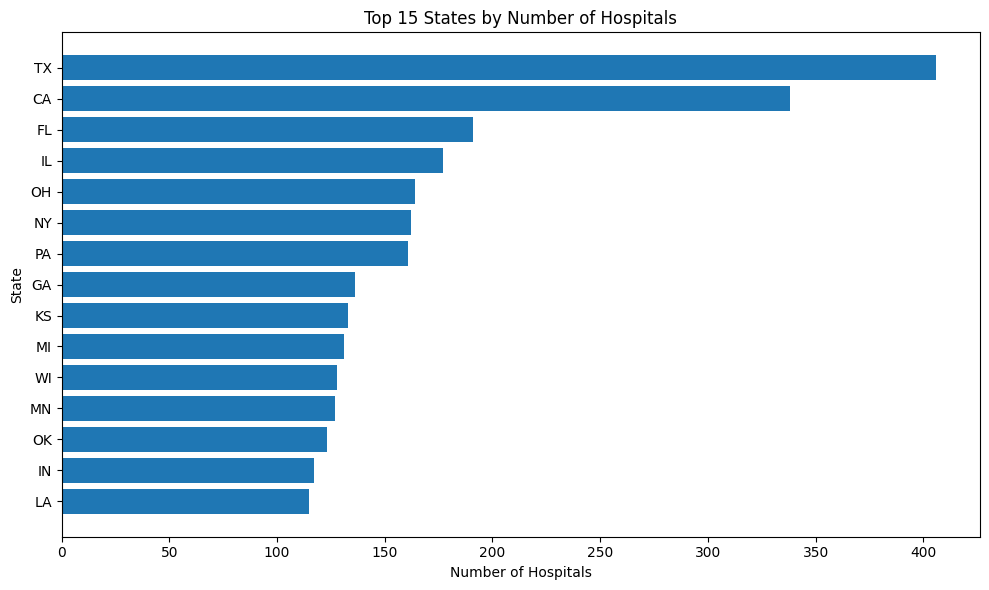

In [35]:
# Plot the top 15 states by hospital count

top_states_by_count = hospitals_by_state.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states_by_count.index[::-1],
    top_states_by_count[
        "hospital_count"
    ][::-1]
)

plt.title("Top 15 States by Number of Hospitals")
plt.xlabel("Number of Hospitals")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [36]:
# Count hospitals by city and state

hospitals_by_city = (
    clean_df.groupby(
        ["state", "city"]
    )
    .agg(
        hospital_count=(
            "facility_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "hospital_count",
        ascending=False
    )
)

hospitals_by_city.head(15)

,state,city,hospital_count
961,IL,CHICAGO,30
3150,TX,HOUSTON,22
3100,TX,DALLAS,18
309,CA,LOS ANGELES,17
2633,OK,OKLAHOMA CITY,17
2791,PA,PHILADELPHIA,16
1489,MD,BALTIMORE,16
189,AZ,PHOENIX,16
3243,TX,SAN ANTONIO,15
2855,PR,SAN JUAN,14


In [37]:
# Calculate state-level patient-experience performance

state_performance = (
    experience_df.groupby("state")
    .agg(
        hospital_count=(
            "facility_id",
            "nunique"
        ),
        average_overall_rating=(
            "overall_rating",
            "mean"
        ),
        average_nurse_communication=(
            "nurse_communication",
            "mean"
        ),
        average_doctor_communication=(
            "doctor_communication",
            "mean"
        ),
        average_discharge_information=(
            "discharge_information",
            "mean"
        ),
        average_patient_recommendation=(
            "patient_recommendation",
            "mean"
        )
    )
    .reset_index()
)

state_performance.head()

,state,hospital_count,average_overall_rating,average_nurse_communication,average_doctor_communication,average_discharge_information,average_patient_recommendation
0,AK,11,3.55,91.91,91.45,86.45,89.45
1,AL,53,3.25,91.09,91.28,84.53,86.15
2,AR,37,3.27,91.46,91.35,84.51,87.35
3,AZ,65,2.86,90.38,88.74,83.69,85.55
4,CA,278,2.87,89.66,89.03,84.54,85.59


### Minimum Sample-Size Rule

Comparing state averages can be misleading when a state contains only a small number of reporting hospitals.

To improve reliability, only states with at least 20 hospitals containing complete patient-experience data will be included in state performance rankings.

In [38]:
# Keep states with at least 20 reporting hospitals

minimum_hospital_count = 20

reliable_state_performance = state_performance[
    state_performance["hospital_count"]
    >= minimum_hospital_count
].copy()

print(
    "States included in reliable comparison:",
    len(reliable_state_performance)
)

States included in reliable comparison: 42


In [39]:
# Identify states with the highest patient recommendation scores

highest_recommendation_states = (
    reliable_state_performance
    .sort_values(
        "average_patient_recommendation",
        ascending=False
    )
    .head(10)
)

highest_recommendation_states[
    [
        "state",
        "hospital_count",
        "average_patient_recommendation"
    ]
]

,state,hospital_count,average_patient_recommendation
29,NE,35,89.57
50,WI,100,89.57
45,UT,34,89.56
13,ID,24,89.46
23,MN,70,89.34
26,MT,20,89.25
16,KS,50,89.20
21,ME,25,89.08
5,CO,56,88.89
37,OR,45,88.89


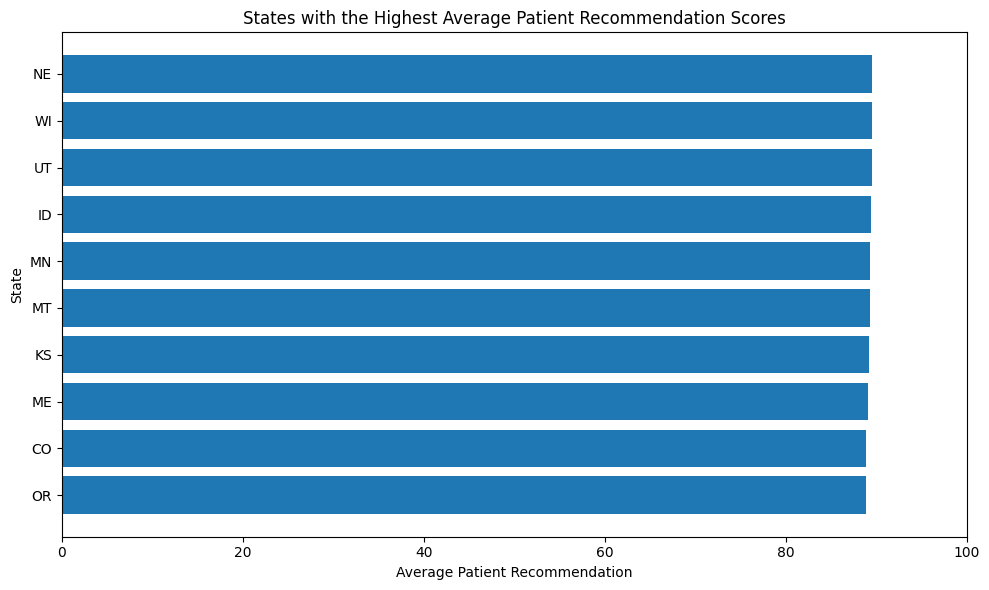

In [40]:
# Plot states with the highest recommendation scores

plot_data = (
    highest_recommendation_states
    .sort_values(
        "average_patient_recommendation"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["state"],
    plot_data[
        "average_patient_recommendation"
    ]
)

plt.title(
    "States with the Highest Average "
    "Patient Recommendation Scores"
)
plt.xlabel("Average Patient Recommendation")
plt.ylabel("State")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [41]:
# Identify states with the lowest patient recommendation scores

lowest_recommendation_states = (
    reliable_state_performance
    .sort_values(
        "average_patient_recommendation",
        ascending=True
    )
    .head(10)
)

lowest_recommendation_states[
    [
        "state",
        "hospital_count",
        "average_patient_recommendation"
    ]
]

,state,hospital_count,average_patient_recommendation
34,NY,134,84.34
32,NM,26,84.46
31,NJ,60,84.48
20,MD,42,84.93
9,FL,166,85.12
33,NV,26,85.23
3,AZ,65,85.55
4,CA,278,85.59
22,MI,97,85.60
14,IL,117,85.90


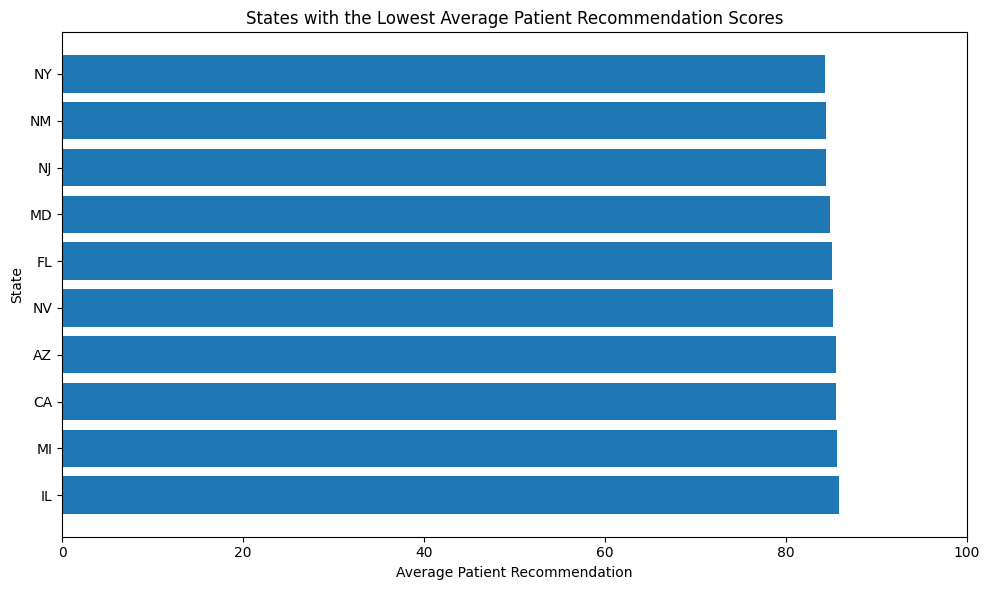

In [42]:
# Plot states with the lowest recommendation scores

plot_data = (
    lowest_recommendation_states
    .sort_values(
        "average_patient_recommendation",
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["state"],
    plot_data[
        "average_patient_recommendation"
    ]
)

plt.title(
    "States with the Lowest Average "
    "Patient Recommendation Scores"
)
plt.xlabel("Average Patient Recommendation")
plt.ylabel("State")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis

Bivariate analysis examines relationships between two variables.

The primary target variable is `patient_recommendation`.

The analysis tests whether patient recommendations are associated with:

- Nurse communication.
- Doctor communication.
- Discharge information.
- Overall hospital rating.

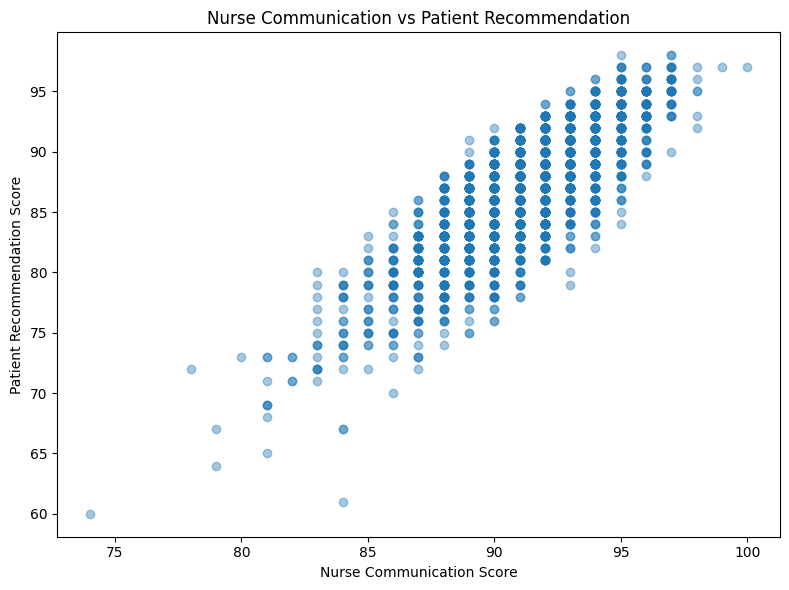

In [43]:
# Nurse communication versus patient recommendation

plt.figure(figsize=(8, 6))

plt.scatter(
    experience_df["nurse_communication"],
    experience_df["patient_recommendation"],
    alpha=0.4
)

plt.title(
    "Nurse Communication vs Patient Recommendation"
)
plt.xlabel("Nurse Communication Score")
plt.ylabel("Patient Recommendation Score")
plt.tight_layout()
plt.show()

In [44]:
# Calculate nurse communication correlation

nurse_recommendation_correlation = (
    experience_df["nurse_communication"]
    .corr(
        experience_df[
            "patient_recommendation"
        ]
    )
)

print(
    "Correlation between nurse communication "
    "and patient recommendation:",
    f"{nurse_recommendation_correlation:.3f}"
)

Correlation between nurse communication and patient recommendation: 0.808


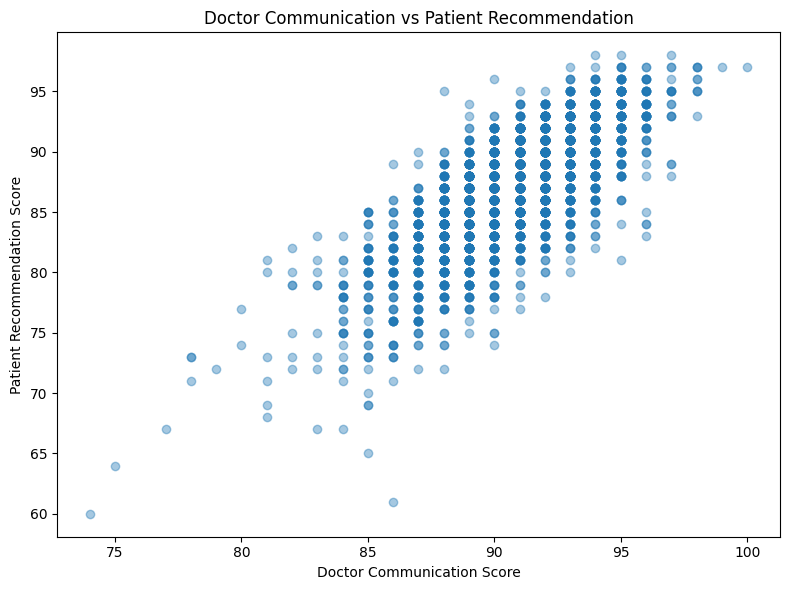

In [45]:
# Doctor communication versus patient recommendation

plt.figure(figsize=(8, 6))

plt.scatter(
    experience_df["doctor_communication"],
    experience_df["patient_recommendation"],
    alpha=0.4
)

plt.title(
    "Doctor Communication vs Patient Recommendation"
)
plt.xlabel("Doctor Communication Score")
plt.ylabel("Patient Recommendation Score")
plt.tight_layout()
plt.show()

In [46]:
# Calculate doctor communication correlation

doctor_recommendation_correlation = (
    experience_df["doctor_communication"]
    .corr(
        experience_df[
            "patient_recommendation"
        ]
    )
)

print(
    "Correlation between doctor communication "
    "and patient recommendation:",
    f"{doctor_recommendation_correlation:.3f}"
)

Correlation between doctor communication and patient recommendation: 0.752


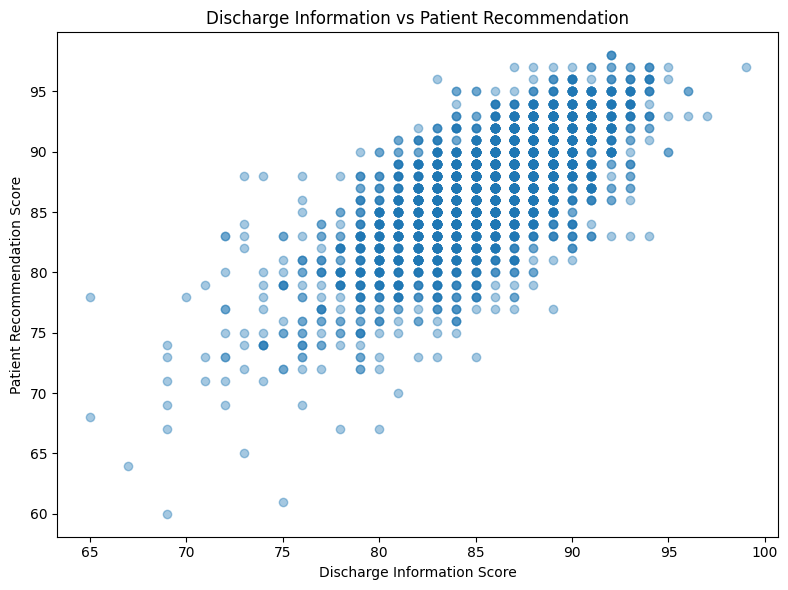

In [47]:
# Discharge information versus patient recommendation

plt.figure(figsize=(8, 6))

plt.scatter(
    experience_df["discharge_information"],
    experience_df["patient_recommendation"],
    alpha=0.4
)

plt.title(
    "Discharge Information vs Patient Recommendation"
)
plt.xlabel("Discharge Information Score")
plt.ylabel("Patient Recommendation Score")
plt.tight_layout()
plt.show()

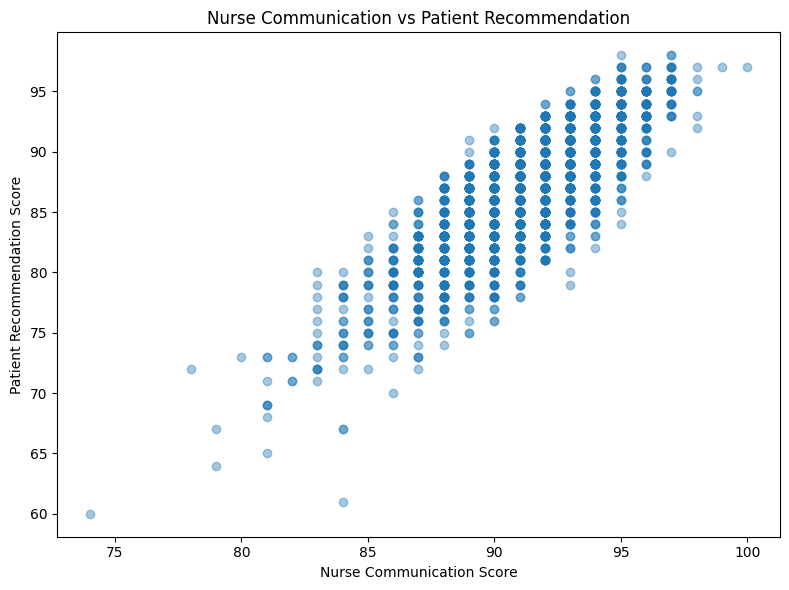

In [48]:
# Nurse communication versus patient recommendation

plt.figure(figsize=(8, 6))

plt.scatter(
    experience_df["nurse_communication"],
    experience_df["patient_recommendation"],
    alpha=0.4
)

plt.title(
    "Nurse Communication vs Patient Recommendation"
)
plt.xlabel("Nurse Communication Score")
plt.ylabel("Patient Recommendation Score")
plt.tight_layout()
plt.show()

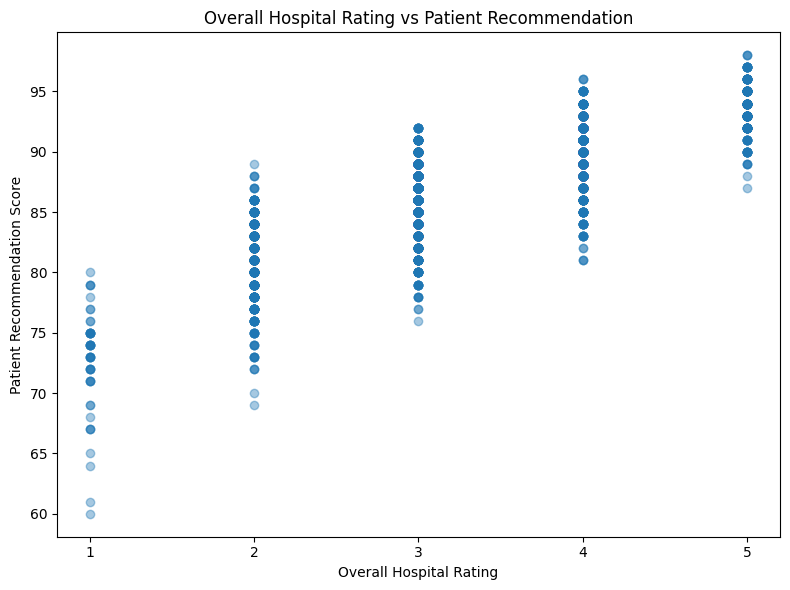

In [49]:
# Overall rating versus patient recommendation

plt.figure(figsize=(8, 6))

plt.scatter(
    experience_df["overall_rating"],
    experience_df["patient_recommendation"],
    alpha=0.4
)

plt.title(
    "Overall Hospital Rating vs "
    "Patient Recommendation"
)
plt.xlabel("Overall Hospital Rating")
plt.ylabel("Patient Recommendation Score")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

In [50]:
# Compare average recommendation by overall rating

recommendation_by_rating = (
    experience_df.groupby(
        "overall_rating"
    )["patient_recommendation"]
    .agg(["count", "mean", "median"])
)

recommendation_by_rating

,count,mean,median
overall_rating,,,
1.00,51,72.69,74.00
2.00,501,81.03,81.00
3.00,1344,86.20,86.00
4.00,1037,89.95,90.00
5.00,243,93.67,94.00


### Bivariate Analysis Note

A positive correlation indicates that two variables tend to increase together.

A negative correlation indicates that one variable tends to decrease as the other increases.

Correlation does not prove causation. Therefore, the results show statistical association but do not prove that one factor directly causes another.

## 9. Correlation Analysis

A correlation matrix summarises the linear relationships between all numerical patient-experience variables.

The values range from -1 to 1:

- Values close to 1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak linear relationship.

In [51]:
# Calculate the correlation matrix

correlation_matrix = (
    experience_df[numeric_columns]
    .corr()
)

correlation_matrix

,overall_rating,nurse_communication,doctor_communication,discharge_information,patient_recommendation
overall_rating,1.00,0.87,0.82,0.78,0.81
nurse_communication,0.87,1.00,0.81,0.77,0.81
doctor_communication,0.82,0.81,1.00,0.69,0.75
discharge_information,0.78,0.77,0.69,1.00,0.71
patient_recommendation,0.81,0.81,0.75,0.71,1.00


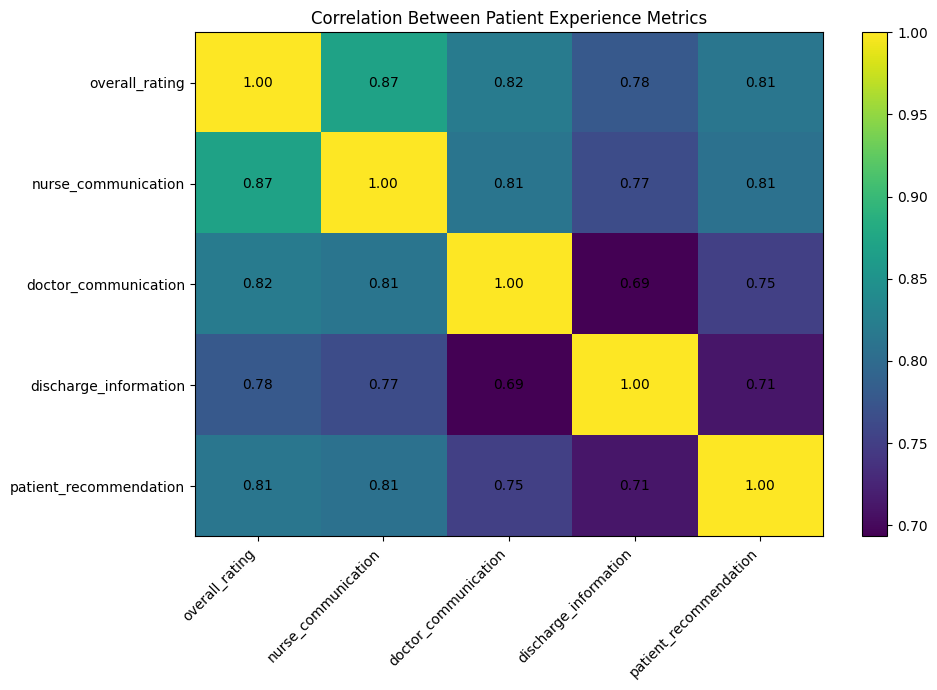

In [52]:
# Plot the correlation matrix

fig, ax = plt.subplots(figsize=(10, 7))

image = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_matrix.index
)

for row_index in range(
    len(correlation_matrix.index)
):
    for column_index in range(
        len(correlation_matrix.columns)
    ):
        value = correlation_matrix.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image)
plt.title(
    "Correlation Between Patient Experience Metrics"
)
plt.tight_layout()
plt.show()

In [53]:
# Rank correlations with patient recommendation

recommendation_correlations = (
    correlation_matrix[
        "patient_recommendation"
    ]
    .drop("patient_recommendation")
    .sort_values(
        ascending=False
    )
)

recommendation_correlations

overall_rating          0.81
nurse_communication     0.81
doctor_communication    0.75
discharge_information   0.71
Name: patient_recommendation, dtype: float64

## 10. Outlier Analysis

Boxplots are used to identify unusually low or high patient-experience scores.

Low scores should not automatically be removed because they may represent genuine underperforming hospitals.

These hospitals are important for identifying improvement and technology opportunities.


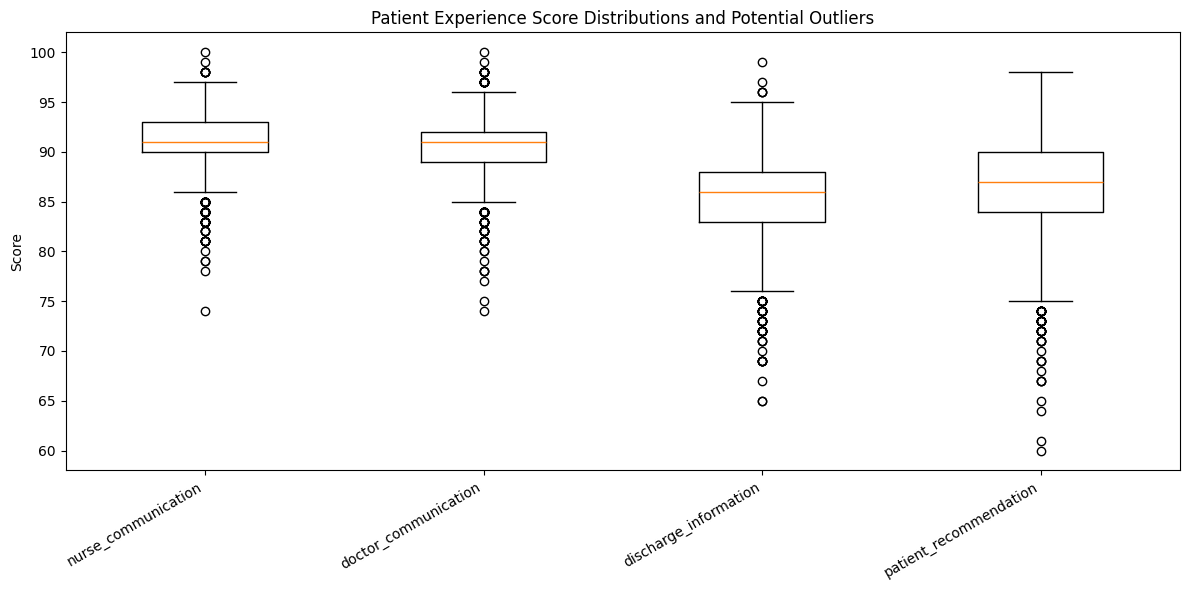

In [54]:
# Plot boxplots for patient-experience metrics

plt.figure(figsize=(12, 6))

plt.boxplot(
    [
        experience_df[column].dropna()
        for column in percentage_columns
    ],
    tick_labels=percentage_columns
)

plt.title(
    "Patient Experience Score Distributions "
    "and Potential Outliers"
)
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [55]:
# Detect outliers using the interquartile range (IQR) method
outlier_columns = numeric_columns

outlier_summary_rows = []

for column in outlier_columns:
    q1 = experience_df[column].quantile(0.25)
    q3 = experience_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    is_outlier = (
        (experience_df[column] < lower_bound)
        | (experience_df[column] > upper_bound)
    )

    outlier_summary_rows.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(is_outlier.sum()),
        "outlier_percentage": round(is_outlier.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary_rows).set_index("column")
outlier_summary

,lower_bound,upper_bound,outlier_count,outlier_percentage
column,,,,
overall_rating,1.50,5.50,51,1.61
nurse_communication,85.50,97.50,91,2.87
doctor_communication,84.50,96.50,86,2.71
discharge_information,75.50,95.50,61,1.92
patient_recommendation,75.00,99.00,49,1.54


In [56]:
# Inspect the hospitals with the lowest patient recommendation scores
lowest_recommendation_hospitals = (
    experience_df
    .sort_values("patient_recommendation")
    [["facility_name", "state", "patient_recommendation", "overall_rating"]]
    .head(10)
)
lowest_recommendation_hospitals

,facility_name,state,patient_recommendation,overall_rating
459,COAST PLAZA HOSPITAL,CA,60.00,1.00
1436,VISTA MEDICAL CENTER EAST,IL,61.00,1.00
418,LOS ANGELES COMMUNITY HOSPITAL,CA,64.00,1.00
2075,SINAI-GRACE HOSPITAL,MI,65.00,1.00
376,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,67.00,1.00
473,OROVILLE HOSPITAL,CA,67.00,1.00
374,HEMET GLOBAL MEDICAL CENTER,CA,67.00,1.00
2846,CAREWELL HEALTH MEDICAL CENTER,NJ,68.00,1.00
362,MEMORIAL HOSPITAL OF GARDENA,CA,69.00,1.00
1304,ROSELAND COMMUNITY HOSPITAL,IL,69.00,2.00


### Outlier Interpretation

The IQR method flags relatively few outliers across the patient-experience metrics, and the flagged values sit mostly on the low end of the score range rather than the high end.

These low-scoring hospitals are not data-entry errors; the score ranges and duplicate checks performed earlier confirm the values are valid. They represent genuinely underperforming hospitals and are kept in the dataset, since they are the hospitals most likely to benefit from a technology intervention.

## 11. Summary of Key Findings

This section brings together the answers to the research questions defined at the start of the notebook.

**1. Distribution of overall hospital ratings**
Ratings are concentrated around the middle of the scale. A rating of 3 is the most common, followed by 4, while ratings of 1 and 5 are the least common.

**2. Average patient-experience scores**
Nurse communication (91.24) and doctor communication (90.67) have the highest average scores. Discharge information (85.66) has the lowest average score, making it the most common improvement area.

**3. States with the largest number of hospitals**
Texas, California, Florida, Illinois, and Ohio report the largest numbers of hospitals.

**4. States with the highest and lowest patient recommendation scores**
Among states with at least 20 reporting hospitals, Wisconsin and Nebraska have the highest average patient recommendation scores, while New York and New Mexico have the lowest.

**5-7. Association between communication/discharge measures and patient recommendation**
Nurse communication (r = 0.81), doctor communication (r = 0.75), and discharge information (r = 0.71) are all positively and strongly correlated with patient recommendation.

**8. Strongest relationship with patient recommendation**
Overall rating (r = 0.81) and nurse communication (r = 0.81) show the strongest relationships with patient recommendation, followed by doctor communication and discharge information.

**Data quality**
About a third of hospitals (33.72%) are missing at least one patient-experience score. These records were excluded from `experience_df` rather than imputed, since imputing a rating could misrepresent hospital performance. No duplicate rows or duplicate facility IDs were found, and all scores fall within their valid ranges.

### Next Steps

Research questions 9 and 10 - identifying hospitals with multiple low-performing indicators and recommending digital solutions - require building a technology opportunity score on top of this EDA. That scoring and recommendation step is addressed in the next stage of the project, outside the scope of the exploratory analysis above.

## 12. Hospitals with Multiple Low-Performing Indicators

A hospital that scores poorly on a single measure may just need a small fix. A hospital that scores poorly on several measures at once is a stronger and more urgent candidate for a broader technology intervention.

Rather than picking arbitrary cut-offs, a hospital is flagged as "low-performing" on a metric if its score falls in the bottom 25% (first quartile) of that metric nationally. This keeps the definition data-driven and comparable across metrics that use different scales.

In [57]:
# Flag hospitals scoring in the bottom quartile on each driver metric
driver_columns = [
    "nurse_communication",
    "doctor_communication",
    "discharge_information"
]

scored_df = experience_df.copy()

for column in driver_columns:
    threshold = experience_df[column].quantile(0.25)
    scored_df[f"low_{column}"] = scored_df[column] <= threshold

# Count how many indicators each hospital is weak on
scored_df["low_indicator_count"] = scored_df[
    [f"low_{column}" for column in driver_columns]
].sum(axis=1)

low_indicator_distribution = (
    scored_df["low_indicator_count"]
    .value_counts()
    .sort_index()
)
low_indicator_distribution

low_indicator_count
0    1733
1     527
2     417
3     499
Name: count, dtype: int64

### Interpretation

Most hospitals are not weak everywhere - the majority score outside the bottom quartile on all three drivers. A smaller group struggles on exactly one measure and could likely be helped with a targeted, single-purpose tool. The hospitals weak on two or three indicators at once are the priority segment: their patient-experience problems are systemic rather than isolated, which points toward a broader patient-engagement platform rather than a point solution.

## 13. Technology Opportunity Score

Section 9 showed that nurse communication, doctor communication, and discharge information are all positively correlated with patient recommendation, but not equally so (r = 0.81, 0.75, and 0.71 respectively). A hospital's technology opportunity should weigh underperformance on the metric that matters most to patients more heavily.

The **Technology Opportunity Score** is built as follows:

1. For each driver metric, convert the score into a *gap* (`100 - score`), so a higher gap means more room to improve.
2. Weight each gap by that metric's correlation strength with patient recommendation, so improving the metric with the strongest link to patient recommendation contributes the most to the score.
3. Sum the weighted gaps into a single 0-100 style score, where a higher score means a larger, more patient-impactful technology opportunity.

In [58]:
# Derive weights from each driver's correlation with patient recommendation
driver_correlations = correlation_matrix.loc[driver_columns, "patient_recommendation"]
driver_weights = driver_correlations / driver_correlations.sum()

driver_weights

nurse_communication     0.36
doctor_communication    0.33
discharge_information   0.31
Name: patient_recommendation, dtype: float64

In [59]:
# Calculate the weighted Technology Opportunity Score
tech_opportunity_score = sum(
    (100 - scored_df[column]) * driver_weights[column]
    for column in driver_columns
)

scored_df["tech_opportunity_score"] = tech_opportunity_score.round(2)

scored_df[
    ["facility_name", "state", "tech_opportunity_score", "low_indicator_count"]
].sort_values("tech_opportunity_score", ascending=False).head(15)

,facility_name,state,tech_opportunity_score,low_indicator_count
459,COAST PLAZA HOSPITAL,CA,27.57,3
418,LOS ANGELES COMMUNITY HOSPITAL,CA,26.08,3
376,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,24.79,3
2846,CAREWELL HEALTH MEDICAL CENTER,NJ,24.01,3
377,HUNTINGTON BEACH HOSPITAL,CA,23.40,3
380,CENTINELA HOSPITAL MEDICAL CENTER,CA,23.12,3
790,DELRAY MEDICAL CENTER,FL,22.76,3
564,SHERMAN OAKS HOSPITAL,CA,22.38,3
412,EAST LOS ANGELES DOCTORS HOSPITAL,CA,21.83,3
3141,ST JOSEPH'S MEDICAL CENTER,NY,21.62,3


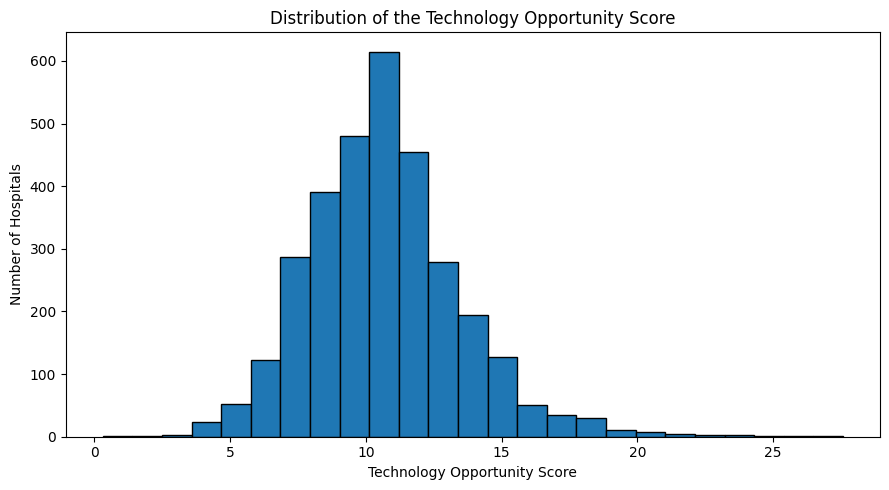

In [60]:
# Plot the distribution of the Technology Opportunity Score
plt.figure(figsize=(9, 5))
plt.hist(
    scored_df["tech_opportunity_score"],
    bins=25,
    edgecolor="black"
)
plt.title("Distribution of the Technology Opportunity Score")
plt.xlabel("Technology Opportunity Score")
plt.ylabel("Number of Hospitals")
plt.tight_layout()
plt.show()

### Interpretation

Most hospitals cluster in a moderate opportunity range, with a smaller tail of hospitals carrying notably higher scores. That tail - roughly the top decile - represents the hospitals where a digital patient-experience intervention would have the largest expected impact on patient recommendation.

## 14. Mapping Weak Areas to Digital Solutions

Each driver metric maps to a category of digital solution that directly targets that part of the patient journey:

| Weakest Metric | Recommended Digital Solution |
|---|---|
| Nurse communication | Real-time nurse rounding & bedside communication app |
| Doctor communication | Post-visit physician messaging / telehealth follow-up platform |
| Discharge information | Digital discharge-instructions & care-transition app |

For each hospital, the weakest of the three driver metrics determines which solution is recommended.

In [61]:
# Identify each hospital's weakest driver metric and map it to a solution
solution_map = {
    "nurse_communication": "Nurse rounding & communication app",
    "doctor_communication": "Physician messaging / telehealth follow-up platform",
    "discharge_information": "Digital discharge-instructions app"
}

scored_df["weakest_area"] = scored_df[driver_columns].idxmin(axis=1)
scored_df["recommended_solution"] = scored_df["weakest_area"].map(solution_map)

scored_df[["facility_name", "state", "weakest_area", "recommended_solution"]].head()

,facility_name,state,weakest_area,recommended_solution
0,ALASKA NATIVE MEDICAL CENTER,AK,discharge_information,Digital discharge-instructions app
1,ALASKA REGIONAL HOSPITAL,AK,discharge_information,Digital discharge-instructions app
2,PROVIDENCE ALASKA MEDICAL CENTER,AK,doctor_communication,Physician messaging / telehealth follow-up pla...
4,YUKON KUSKOKWIM DELTA REG HOSPITAL,AK,discharge_information,Digital discharge-instructions app
7,FAIRBANKS MEMORIAL HOSPITAL,AK,discharge_information,Digital discharge-instructions app


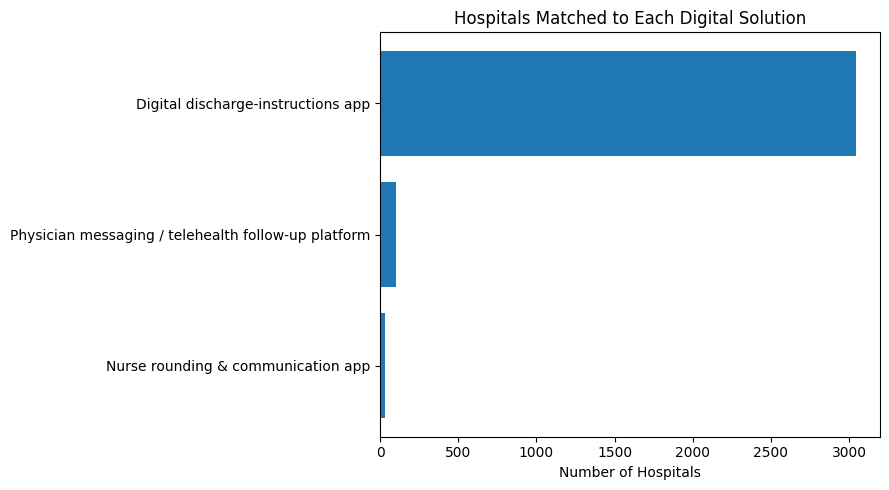

recommended_solution
Digital discharge-instructions app                     3045
Physician messaging / telehealth follow-up platform     102
Nurse rounding & communication app                       29
Name: count, dtype: int64

In [62]:
# Count national demand for each recommended solution
solution_demand = (
    scored_df["recommended_solution"]
    .value_counts()
)

plt.figure(figsize=(9, 5))
plt.barh(
    solution_demand.index[::-1],
    solution_demand.values[::-1]
)
plt.title("Hospitals Matched to Each Digital Solution")
plt.xlabel("Number of Hospitals")
plt.tight_layout()
plt.show()

solution_demand

### Interpretation

The solution with the largest number of matched hospitals represents the single biggest market opportunity nationally - it is the area where the most hospitals share the same weakest link in the patient experience, and where one product could serve the largest number of hospitals.

In [63]:
# Build the final priority list for stakeholders: highest-opportunity hospitals first
priority_hospitals = (
    scored_df
    .sort_values("tech_opportunity_score", ascending=False)
    [[
        "facility_name",
        "state",
        "overall_rating",
        "low_indicator_count",
        "weakest_area",
        "recommended_solution",
        "tech_opportunity_score"
    ]]
    .head(20)
    .reset_index(drop=True)
)
priority_hospitals

,facility_name,state,overall_rating,low_indicator_count,weakest_area,recommended_solution,tech_opportunity_score
0,COAST PLAZA HOSPITAL,CA,1.00,3,discharge_information,Digital discharge-instructions app,27.57
1,LOS ANGELES COMMUNITY HOSPITAL,CA,1.00,3,discharge_information,Digital discharge-instructions app,26.08
2,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,1.00,3,discharge_information,Digital discharge-instructions app,24.79
3,CAREWELL HEALTH MEDICAL CENTER,NJ,1.00,3,discharge_information,Digital discharge-instructions app,24.01
4,HUNTINGTON BEACH HOSPITAL,CA,1.00,3,discharge_information,Digital discharge-instructions app,23.40
5,CENTINELA HOSPITAL MEDICAL CENTER,CA,1.00,3,discharge_information,Digital discharge-instructions app,23.12
6,DELRAY MEDICAL CENTER,FL,1.00,3,discharge_information,Digital discharge-instructions app,22.76
7,SHERMAN OAKS HOSPITAL,CA,1.00,3,discharge_information,Digital discharge-instructions app,22.38
8,EAST LOS ANGELES DOCTORS HOSPITAL,CA,1.00,3,discharge_information,Digital discharge-instructions app,21.83
9,ST JOSEPH'S MEDICAL CENTER,NY,1.00,3,discharge_information,Digital discharge-instructions app,21.62


## 15. Executive Summary & Recommendations

**Business problem.** Hospitals collect patient-experience survey data, but the raw scores alone do not show where to focus improvement efforts or which technology could help.

**Data quality.** The dataset covers 4,792 hospitals with no duplicate records. About a third of hospitals (33.72%) are missing at least one patient-experience score and were excluded from the scored analysis rather than imputed, to avoid misrepresenting hospital performance.

**Key patterns.** Discharge information is the weakest patient-experience area on average (85.66), and nurse communication has the strongest relationship with patient recommendation (r = 0.81). Hospital performance varies meaningfully by state, with Wisconsin and Nebraska leading and New York and New Mexico trailing among states with sufficient sample size.

**Technology opportunity.** Weighting each hospital's underperformance by how strongly that metric drives patient recommendation produces a Technology Opportunity Score that ranks hospitals by expected impact rather than raw score alone. A smaller group of hospitals is weak across multiple indicators at once - these are the strongest candidates for a broader patient-engagement platform, while single-area strugglers are better served by a targeted tool.

**Recommendation.** Prioritise pilot deployments in the top-scoring hospitals from Section 14, matched to the solution category driven by each hospital's weakest metric. This targets the limited number of hospitals where a digital intervention is likely to move the patient recommendation outcome the most.

**Limitations.** All relationships in this analysis are correlational, not causal - a strong correlation between communication scores and recommendation does not by itself prove that a new tool will change the outcome. The technology opportunity score is also a modeling choice, weighted by observed correlations from this dataset; validating it against pilot results is a natural next step.